# Notebook 06: Explainable AI (XAI)

## Introduction

Machine learning models can achieve high prediction accuracy, but their decision-making process is often difficult to understand. In healthcare applications, simply providing a prediction is not sufficient. Medical professionals need to understand **why** a prediction was made before they can trust and use it in decision-making.

Explainable Artificial Intelligence (XAI) improves the transparency of machine learning models by identifying the factors that contribute to each prediction. Instead of only predicting whether a patient is at risk of depression, XAI explains how different features influence the model's decision.

In this project, the SHAP (SHapley Additive exPlanations) framework is used to interpret the predictions of the Logistic Regression model. SHAP provides both global explanations (overall feature importance) and local explanations (feature contributions for an individual prediction), making the model more transparent and easier to understand.

## Understanding SHAP Values

SHAP (SHapley Additive exPlanations) assigns a contribution value to each feature for a specific prediction. These values indicate how much each feature influences the model's output.

- **Positive SHAP Value (+):** Pushes the prediction toward the positive class (Depression = Yes).
- **Negative SHAP Value (-):** Pushes the prediction toward the negative class (Depression = No).

The magnitude of the SHAP value represents the strength of the feature's influence. Features with larger absolute SHAP values have a greater impact on the final prediction than features with smaller values.

For example, if **Academic Pressure** has a SHAP value of **+0.50**, it strongly increases the likelihood of predicting depression. Conversely, if **Sleep Duration** has a SHAP value of **-0.20**, it reduces the likelihood of predicting depression.

In [3]:
# Data Manipulation
import pandas as pd
import numpy as np

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Explainable AI
import shap

# Visualization
import matplotlib.pyplot as plt

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("../Dataset/Processed/MindSense_AI_Cleaned_Dataset_v1.csv")

df.head()

,Gender,Age,Working Professional or Student,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,...,Degree_M.Tech,Degree_MA,Degree_MBA,Degree_MBBS,Degree_MCA,Degree_MD,Degree_ME,Degree_MHM,Degree_MSc,Degree_PhD
0,0,37,1,-1.0,2.0,-1.0,-1.0,4.0,2,1,...,0,1,0,0,0,0,0,0,0,0
1,1,60,1,-1.0,4.0,-1.0,-1.0,3.0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,0,42,1,-1.0,2.0,-1.0,-1.0,3.0,1,1,...,0,0,0,0,0,0,0,0,0,0
3,0,44,1,-1.0,3.0,-1.0,-1.0,5.0,2,2,...,0,0,0,0,0,1,0,0,0,0
4,1,48,1,-1.0,4.0,-1.0,-1.0,3.0,2,1,...,0,0,0,0,0,0,0,0,0,0


In [5]:
df["Depression"] = df["Depression"].map({
    "No": 0,
    "Yes": 1
})

In [6]:
X = df.drop("Depression", axis=1)
y = df["Depression"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

## SHAP Explainer

Before interpreting model predictions, an explainer object must be created. The SHAP explainer acts as an interface between the trained machine learning model and the explanation process.

The explainer analyzes the trained model and computes the contribution of each feature toward the model's predictions. Instead of modifying the model, it interprets the model's decision-making process.

In this project, the SHAP explainer is created using the trained Logistic Regression model and the training dataset. Once initialized, it can generate SHAP values for unseen data, allowing both global and local interpretation of predictions.

The SHAP explainer is an essential component because it transforms a machine learning model from a prediction tool into an explainable decision-support system.

In [9]:
# Create SHAP Explainer
explainer = shap.Explainer(model, X_train)

Background dataset has 2044 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=2044 when initializing the masker.


## Generating SHAP Values

After creating the SHAP explainer, the next step is to compute SHAP values for the test dataset.

SHAP values quantify the contribution of each feature toward the model's prediction for every individual sample. These values indicate whether a feature increases or decreases the predicted probability of depression.

The generated SHAP values will be used to create visualizations that explain the model's behavior at both the global and local levels.

In [10]:
# Generate SHAP values for the test dataset
shap_values = explainer(X_test)

## Global Feature Importance using SHAP Summary Plot

The SHAP Summary Plot provides a global interpretation of the machine learning model by visualizing the contribution of each feature across all predictions.

Features are ranked according to their overall importance based on the average magnitude of their SHAP values. Each point in the plot represents one observation, and its position indicates how strongly that feature influenced the prediction.

The color of each point represents the actual feature value:
- **Red:** High feature value
- **Blue:** Low feature value

The horizontal position represents the SHAP value:
- **Positive SHAP values:** Increase the likelihood of predicting depression.
- **Negative SHAP values:** Decrease the likelihood of predicting depression.

The SHAP Summary Plot provides a comprehensive overview of the factors that most strongly influence the model's predictions.

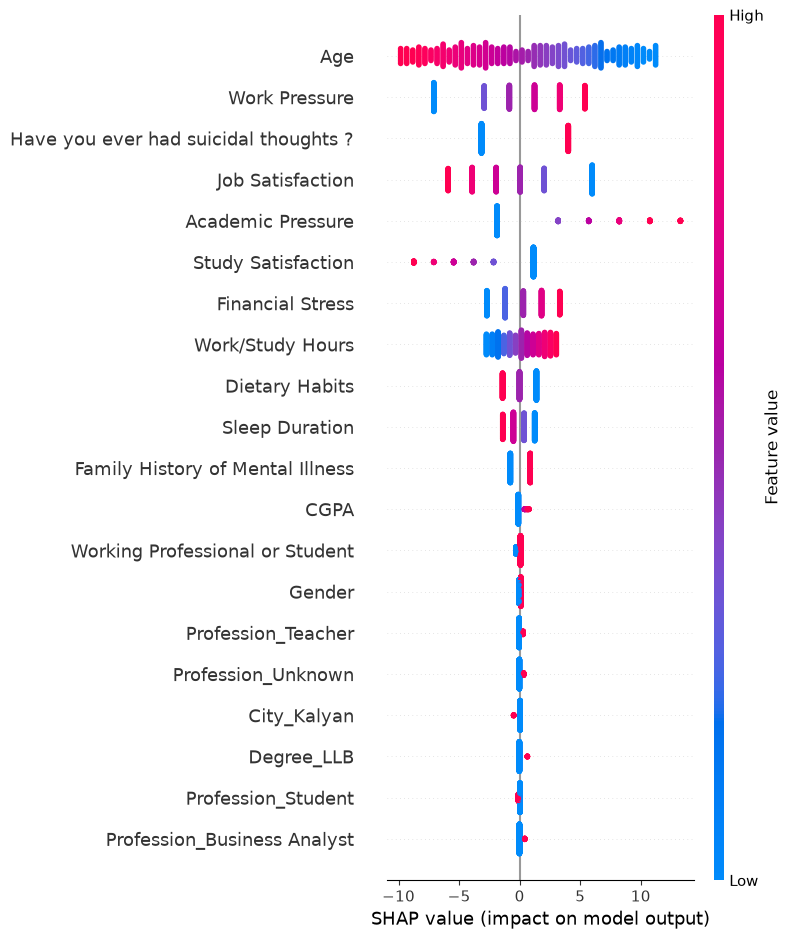

In [11]:
# Global Feature Importance
plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.tight_layout()
plt.show()

### Interpretation of the SHAP Summary Plot

The SHAP Summary Plot provides a global explanation of the trained Logistic Regression model.

The plot ranks features according to their average contribution to the model's predictions. In this project, Age, Work Pressure, Suicidal Thoughts, Job Satisfaction, and Academic Pressure were among the most influential features.

Each point represents one observation from the test dataset. The horizontal position of the point indicates the SHAP value, showing whether the feature pushes the prediction toward or away from depression. Positive SHAP values increase the predicted risk of depression, while negative SHAP values decrease it.

The color of each point represents the actual feature value. Red indicates high feature values, whereas blue indicates low feature values. This visualization helps understand both the importance and the direction of influence of each feature on the model's predictions.

## Local Explanation using SHAP Waterfall Plot

While the SHAP Summary Plot explains the model globally, the SHAP Waterfall Plot explains an individual prediction.

The Waterfall Plot starts from the model's baseline prediction and shows how each feature contributes to the final prediction for a single observation.

Features with positive SHAP values push the prediction toward depression, whereas features with negative SHAP values push it away from depression.

This visualization improves transparency by clearly illustrating why the model produced a particular prediction for an individual.

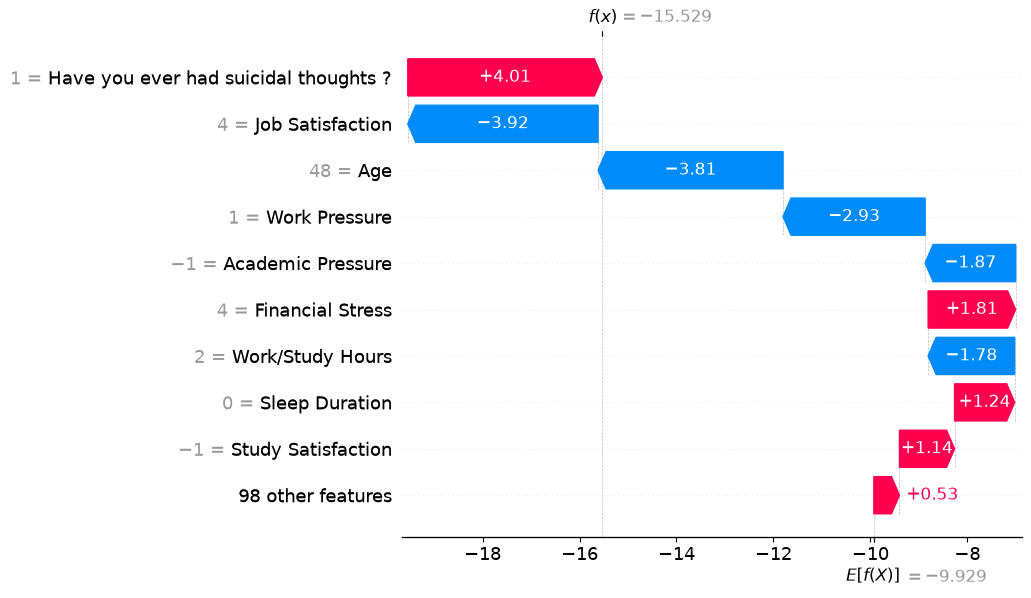

In [12]:
# Explain the first prediction
shap.plots.waterfall(shap_values[0])

### Interpretation of the SHAP Waterfall Plot

The SHAP Waterfall Plot explains the prediction for a single observation. The prediction starts from the model's base value, which represents the average model output, and each feature either increases or decreases the prediction.

Features shown in red have positive SHAP values and increase the model output, while features shown in blue have negative SHAP values and decrease the model output. The length of each bar represents the magnitude of the feature's contribution.

This visualization provides transparency by clearly showing how individual feature contributions combine to produce the model's final prediction for a specific student.

## Local Explanation using SHAP Force Plot

The SHAP Force Plot provides another local explanation by visualizing how different features push the prediction toward or away from the final model output.

Each feature exerts a positive or negative influence on the prediction. Features with positive SHAP values push the prediction in one direction, while features with negative SHAP values push it in the opposite direction.

The Force Plot offers an intuitive visualization of how individual feature contributions combine to produce the final prediction for a single observation.

In [13]:
# Interactive visualization (works best in Jupyter Notebook)
shap.initjs()

shap.plots.force(shap_values[0])

### Interpretation of the SHAP Force Plot

The SHAP Force Plot provides a local explanation for an individual prediction. It starts from the model's base value and visualizes how each feature pushes the prediction toward the final model output.

Features shown in red contribute positively to the model output, while features shown in blue contribute negatively. The length of each segment represents the magnitude of that feature's contribution.

Unlike the SHAP Summary Plot, which explains the model globally, the Force Plot focuses on a single observation, making it useful for understanding why the model produced a specific prediction.